## Loading individual methods' files needed for Axis 1 and Axis 2

In [1]:
import numpy as np
import pandas as pd

In [2]:
# Chen - TF-IDF

tfidf_dist = np.load('files_required/tfidf_centroid_distances.npy')
tfidf_silhouette_scores = float(np.load('files_required/tfidf_silhouette.npy')[0])
df_classifier = pd.read_csv('files_required/classifier_top_words.csv')
print("TF-IDF's centroid distances :",tfidf_dist)
print("TF-IDF's silhouette scores :",round(tfidf_silhouette_scores,4))
print(df_classifier.head())

TF-IDF's centroid distances : [0.259486 0.288921]
TF-IDF's silhouette scores : 0.0015
                   word  coefficient     period direction
0  planning competition     2.004924  2007-2011  positive
1          web services     1.749023  2007-2011  positive
2    language resources     1.723907  2007-2011  positive
3    global constraints     1.633852  2007-2011  positive
4      article presents     1.569723  2007-2011  positive


In [3]:
# Nithya - Sbert

sbert_minilm_dist = np.load('files_required/sbert_minilm_centroid_distances_nithya.npy')
sbert_specter_dist = np.load('files_required/sbert_specter_centroid_distances_nithya.npy')
sbert_mpnet_dist = np.load('files_required/sbert_mpnet_centroid_distances_nithya.npy')
df_sbert_silhouette = pd.read_csv('files_required/sbert_silhouette_scores_nithya.csv')
df_sbert_pca = pd.read_csv('files_required/sbert_pca_coords_nithya.csv')
df_framing = pd.read_csv('files_required/sbert_framing_heatmap_nithya.csv',index_col=0)
print('MiniLM distances :',sbert_minilm_dist)
print('SPECTER distances :',sbert_specter_dist)
print('MPNet distances :',sbert_mpnet_dist)
print("Sbert's silhouette scores :")
print(df_sbert_silhouette)
print("Sbert's framing heatmap :")
print(df_framing)

MiniLM distances : [0.0461 0.1221]
SPECTER distances : [0.0055 0.0298]
MPNet distances : [0.05   0.1388]
Sbert's silhouette scores :
     MiniLM     MPNet   Specter
0  0.054125  0.055926  0.017233
Sbert's framing heatmap :
                  2007-2011  2012-2016  2017-2021
state-of-the-art   0.645184   0.653826   0.652376
theoretical        0.716743   0.710527   0.646154
real-world appln   0.704933   0.709778   0.679408
new dataset        0.727063   0.736836   0.724791
scaling up         0.715246   0.720552   0.681753
interpretability   0.651922   0.665724   0.657090


In [4]:
# Rohan - PCA

df_pca_tfidf = pd.read_csv('files_required/pca_tfidf_coordinates.csv')
df_pca_minilm = pd.read_csv('files_required/pca_sbert_minilm_coordinates.csv')
df_pca_specter = pd.read_csv('files_required/pca_sbert_specter_coordinates.csv')
df_pca_mpnet = pd.read_csv('files_required/pca_sbert_mpnet_coordinates.csv')
print("TF-IDF's PCA shape : ",df_pca_tfidf.shape)
print("Specter's PCA shape : ",df_pca_specter.shape)

TF-IDF's PCA shape :  (27121, 5)
Specter's PCA shape :  (27121, 5)


In [5]:
# Shu - Topic Modeling(LDA)

period_topics_lda = pd.read_csv('files_required/lda_period_topics.csv',index_col=0)
lda_centroid_dist = np.load('files_required/lda_period_distances.npy')
lda_silhouette = float(np.load('files_required/lda_overall_silhouette.npy')[0])
topic_words_lda = pd.read_csv('files_required/lda_topic_words.csv')
print('LDA Period-Topic matrix :')
print(period_topics_lda)
print('LDA silhouette:',round(lda_silhouette,4))

LDA Period-Topic matrix :
                 T0        T1        T2        T3        T4        T5  \
period                                                                  
2007-2011  0.009464  0.084385  0.031546  0.179022  0.307571  0.027603   
2012-2016  0.026344  0.072357  0.047636  0.117827  0.211115  0.036629   
2017-2021  0.089311  0.049333  0.106346  0.106740  0.075723  0.063709   

                 T6        T7        T8        T9       T10       T11  
period                                                                 
2007-2011  0.018139  0.022082  0.009464  0.043375  0.237382  0.029968  
2012-2016  0.019848  0.041140  0.046012  0.077228  0.265789  0.038073  
2017-2021  0.075624  0.062134  0.104328  0.156418  0.037270  0.073064  
LDA silhouette: 0.0029


In [6]:
# Clarence - Textrank

df_textrank = pd.read_csv('files_required/textrank_per_period.csv')
df_textrank = df_textrank.rename(columns={'period' : 'year_bin','keyword' : 'keyphrases','score': 'count'}) # to standardise column names
print(df_textrank.head())
print('\nTextrank Data - Periods :',df_textrank['year_bin'].unique())

                    keyphrases  count   year_bin
0       support vector machine     14  2007-2011
1  natural language processing     12  2007-2011
2             machine learning     11  2007-2011
3      artificial intelligence     10  2007-2011
4               neural network      8  2007-2011

Textrank Data - Periods : ['2007-2011' '2012-2016' '2017-2021']


## Axis 1

### Centroid Distance Table (TF-IDF,SBERT,LDA)

In [7]:
import matplotlib.pyplot as plt

In [8]:
YEARS_RANGE = ['2007-2011','2012-2016','2017-2021'] # standardising it for the rest of the code
TRANSITION_YEARS = ['2007-2011 to 2012-2016','2012-2016 to 2017-2021']

In [9]:
dist_results = {}   
dist_results['TF-IDF'] = list(tfidf_dist)
dist_results['SBERT - MiniLM'] = list(sbert_minilm_dist)
dist_results['SBERT - Specter'] = list(sbert_specter_dist)
dist_results['SBERT - MPNet'] = list(sbert_mpnet_dist)
dist_results['LDA'] = [round(lda_centroid_dist[0][1],4),round(lda_centroid_dist[1][2],4)]

df_comparison = pd.DataFrame(dist_results,index=TRANSITION_YEARS).T     # to make the methods as rows
print('Centroid Distance Table :')
print(df_comparison.to_string())
df_comparison['mean_shift'] = df_comparison.mean(axis=1)
print('\nMean Shift :')
print(df_comparison['mean_shift'].sort_values(ascending=False))
df_comparison = df_comparison.drop(columns='mean_shift')


Centroid Distance Table :
                 2007-2011 to 2012-2016  2012-2016 to 2017-2021
TF-IDF                         0.259486                0.288921
SBERT - MiniLM                 0.046100                0.122100
SBERT - Specter                0.005500                0.029800
SBERT - MPNet                  0.050000                0.138800
LDA                            0.027000                0.273300

Mean Shift :
TF-IDF             0.274203
LDA                0.150150
SBERT - MPNet      0.094400
SBERT - MiniLM     0.084100
SBERT - Specter    0.017650
Name: mean_shift, dtype: float64


### Grouped Bar Chart

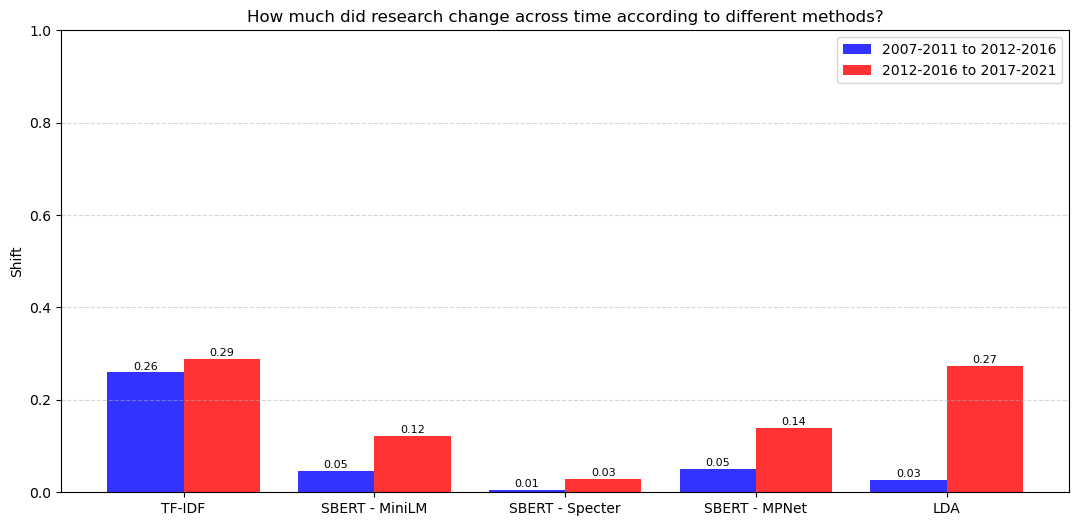

In [10]:
methods = list(df_comparison.index)
x = np.arange(len(methods))
width = 0.4

fig,ax = plt.subplots(figsize=(13,6))
bar_blue = ax.bar(x-width/2,df_comparison[TRANSITION_YEARS[0]],width,label=TRANSITION_YEARS[0],color='blue',alpha=0.8)
bar_red = ax.bar(x+width/2,df_comparison[TRANSITION_YEARS[1]],width,label=TRANSITION_YEARS[1],color='red',alpha=0.8)

# adding the exact values on top 
for bar in bar_blue:
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.002,f'{bar.get_height():.2f}',ha='center',va='bottom',fontsize=8)
for bar in bar_red:
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.002,f'{bar.get_height():.2f}',ha='center',va='bottom',fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylabel('Shift')
ax.set_title('How much did research change across time according to different methods?')
ax.legend()
ax.set_ylim(0,1)
ax.grid(axis='y',linestyle='--',alpha=0.5)
plt.savefig('final_figures/axis1_grouped_bar_chart.png',dpi=150,bbox_inches='tight')
plt.show()

### Silhouette Score Comparison - Separation of 3 periods' clusters

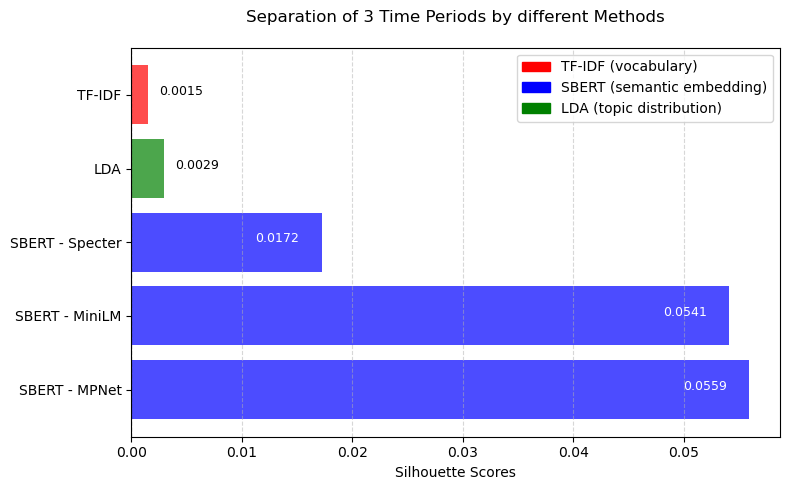

In [11]:
import matplotlib.patches as mpatches

sbert_sil_row = df_sbert_silhouette.iloc[0]
silhouette_results = {'TF-IDF':tfidf_silhouette_scores,'SBERT - MiniLM':float(df_sbert_silhouette['MiniLM'].iloc[0]),'SBERT - Specter':float(df_sbert_silhouette['Specter'].iloc[0]),'SBERT - MPNet':float(df_sbert_silhouette['MPNet'].iloc[0]),'LDA':lda_silhouette}
sil_series = pd.Series(silhouette_results).sort_values(ascending=False)

fig,ax = plt.subplots(figsize=(8, 5))
clrs = []
for i in sil_series.index:
    if 'TF-IDF' in i:
        clrs.append('red')
    elif 'LDA' in i:
        clrs.append('green')
    else:
        clrs.append('blue')
bar = ax.barh(sil_series.index,sil_series.values,color=clrs,alpha=0.7)
for bar,val in zip(bar,sil_series.values):
    if val<0.01:
        ax.text(bar.get_width()+0.001,bar.get_y()+bar.get_height()/2,f'{val:.4f}',ha='left',fontsize=9,color='black')
    else:
        ax.text(bar.get_width()-0.002,bar.get_y()+bar.get_height()/2,f'{val:.4f}',ha='right',fontsize=9,color='white')
ax.set_xlabel('Silhouette Scores')
ax.set_title('Separation of 3 Time Periods by different Methods\n')
ax.axvline(0,color='black',linewidth=0.8,linestyle='--')
legend_patches = [mpatches.Patch(color='red',label='TF-IDF (vocabulary)'),mpatches.Patch(color='blue',label='SBERT (semantic embedding)'),mpatches.Patch(color='green',label='LDA (topic distribution)')]
ax.legend(handles=legend_patches)
ax.grid(axis='x',linestyle='--',alpha=0.5)
plt.tight_layout()
plt.savefig('final_figures/axis1_silhouette_scores.png',dpi=150,bbox_inches='tight')
plt.show()

### PCA Trajectory (TF-IDF,SBERT)

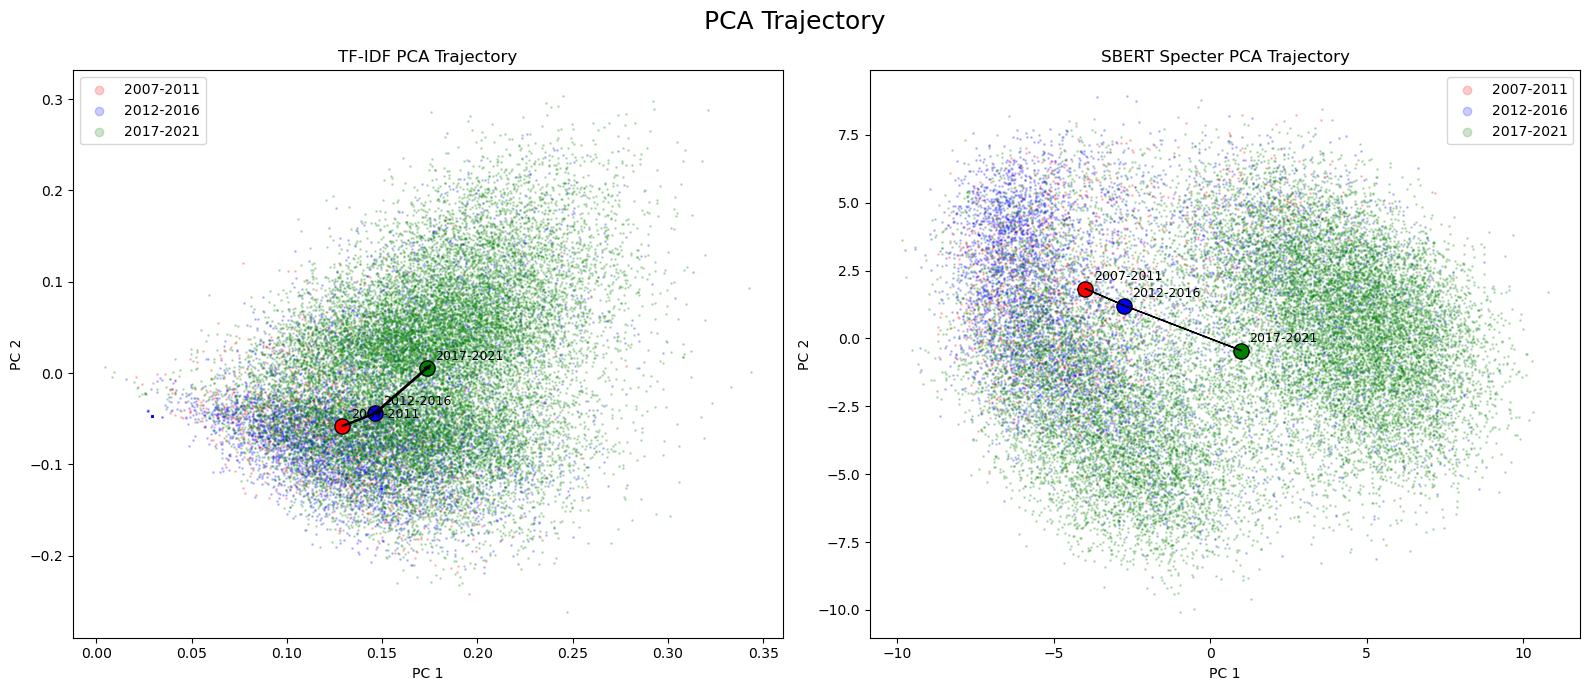

In [12]:
year_clrs = {'2007-2011':'red','2012-2016':'blue','2017-2021':'green'}
year_order = ['2007-2011','2012-2016','2017-2021']

fig,(ax1, ax2) = plt.subplots(1, 2,figsize=(16,7))

# TF-IDF
for period,clr in year_clrs.items():
    mask = df_pca_tfidf['period'] == period
    ax1.scatter(df_pca_tfidf.loc[mask,'x'],df_pca_tfidf.loc[mask,'y'],c=clr,s=1,alpha=0.2,label=period)
tfidf_centroids = df_pca_tfidf.groupby('period')[['x','y']].mean()
for period,clr in year_clrs.items():
    if period in tfidf_centroids.index:
        centroid_x = tfidf_centroids.loc[period,'x']
        centroid_y = tfidf_centroids.loc[period,'y']
        ax1.scatter(centroid_x,centroid_y,c=clr,s=120,edgecolors='black')
        ax1.annotate(period,(centroid_x,centroid_y),xytext=(6,6),textcoords='offset points',fontsize=9)
for i in range(len(year_order)-1):
    yr_1 = year_order[i]
    yr_2 = year_order[i+1]
    x1,y1 = tfidf_centroids.loc[yr_1,'x'],tfidf_centroids.loc[yr_1,'y']
    x2,y2 = tfidf_centroids.loc[yr_2,'x'],tfidf_centroids.loc[yr_2,'y']
    ax1.arrow(x1,y1,x2-x1,y2-y1,fc='black',ec='black')

ax1.set_title('TF-IDF PCA Trajectory')
ax1.set_xlabel('PC 1')
ax1.set_ylabel('PC 2')

# SBERT - Specter
for period,clr in year_clrs.items():
    mask = df_pca_specter['period'] == period
    ax2.scatter(df_pca_specter.loc[mask,'x'], df_pca_specter.loc[mask,'y'],c=clr,s=1,alpha=0.2,label=period)
specter_centroids = df_pca_specter.groupby('period')[['x','y']].mean()
for period,clr in year_clrs.items():
    if period in specter_centroids.index:
        centroid_x = specter_centroids.loc[period,'x']
        centroid_y = specter_centroids.loc[period,'y']
        ax2.scatter(centroid_x,centroid_y,c=clr,s=120,edgecolors='black')
        ax2.annotate(period,(centroid_x,centroid_y),xytext=(6,6),textcoords='offset points',fontsize=9)
for i in range(len(year_order)-1):
    yr_1 = year_order[i]
    yr_2 = year_order[i+1]
    x1,y1 = specter_centroids.loc[yr_1,'x'],specter_centroids.loc[yr_1,'y']
    x2,y2 = specter_centroids.loc[yr_2,'x'],specter_centroids.loc[yr_2,'y']
    ax2.arrow(x1,y1,x2-x1,y2-y1,fc='black',ec='black')

ax2.set_title('SBERT Specter PCA Trajectory')
ax2.set_xlabel('PC 1')
ax2.set_ylabel('PC 2')
ax1.legend(markerscale=6)
ax2.legend(markerscale=6)
plt.suptitle('PCA Trajectory',fontsize=18)
plt.tight_layout()
plt.savefig('final_figures/axis1_pca_trajectory_comparison.png',dpi=150,bbox_inches='tight')
plt.show()

## LDA Topic Shift - Rise and fall of various topics

In [13]:
topic_labels = {}
for col in topic_words_lda.columns:
    top_3 = topic_words_lda[col].dropna().head(3).tolist()    # taking top 3 words to understand what topic they methodresent
    final_topic = []
    for i in top_3 :
        if isinstance(i,tuple):
            final_topic.append(str(i[0]))
        else:
            final_topic.append(str(i))
    topic_labels[col] = '/'.join(final_topic)
lda_labelled = period_topics_lda.copy()
new_colmn_names = []
for c in lda_labelled.columns:
    if c in topic_labels:
        new_colmn_names.append(topic_labels[c])
    else:
        new_colmn_names.append(c)
lda_labelled.columns = new_colmn_names
periods_existing = []
for p in YEARS_RANGE:
    if p in lda_labelled.index:
        periods_existing.append(p)
lda_labelled = lda_labelled.reindex(periods_existing)

In [14]:
# To check which topic number gives which topic
print("Topics :")
for topic,label in topic_labels.items():
    print(f"{topic} means topic realted to {label}")

Topics :
T0 means topic realted to knowledge/text/entity
T1 means topic realted to word/semantic/words
T2 means topic realted to learning/training/classification
T3 means topic realted to time/systems/research
T4 means topic realted to search/optimization/optimal
T5 means topic realted to detection/social/analysis
T6 means topic realted to question/dialogue/generation
T7 means topic realted to task/sentence/state
T8 means topic realted to neural/network/networks
T9 means topic realted to language/translation/languages
T10 means topic realted to inference/logic/probabilistic
T11 means topic realted to learning/agent/policy


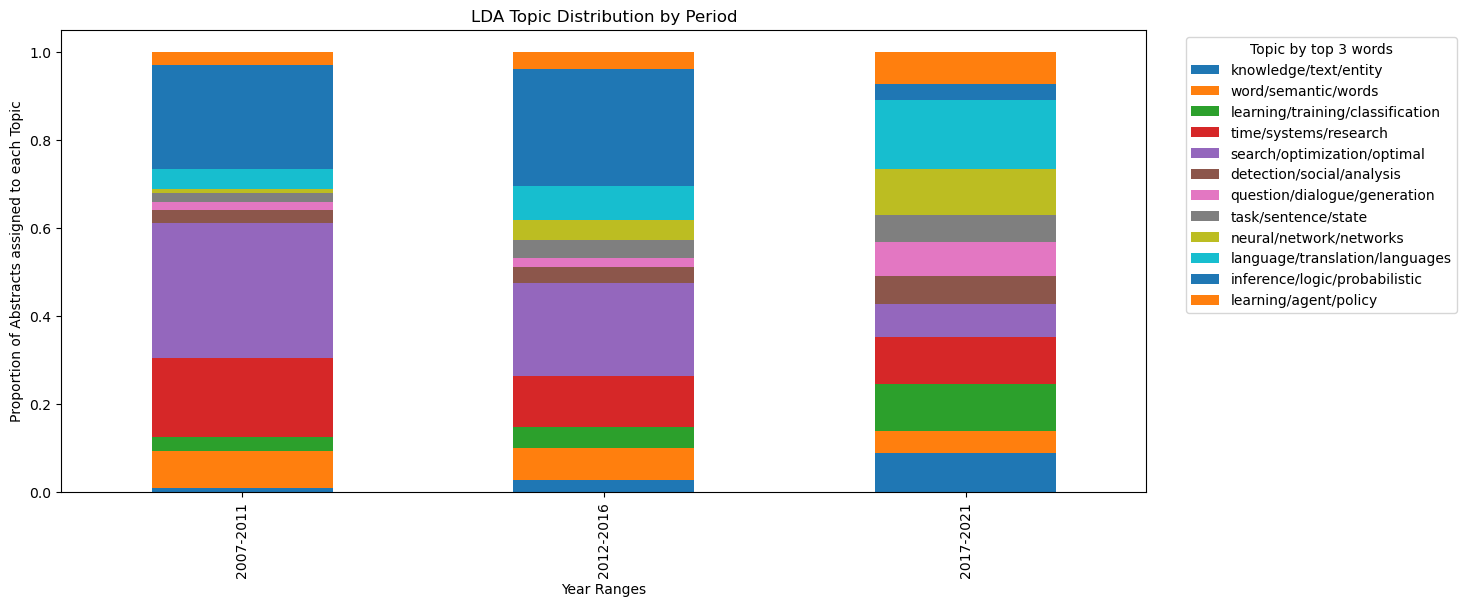

In [15]:
fig,ax = plt.subplots(figsize=(14,6))
lda_labelled.plot(kind='bar',stacked=True,ax=ax,width=0.5)
ax.set_title('LDA Topic Distribution by Period')
ax.set_xlabel('Year Ranges')
ax.set_ylabel('Proportion of Abstracts assigned to each Topic')
ax.set_xticklabels(lda_labelled.index)
ax.legend(title='Topic by top 3 words',bbox_to_anchor=(1.03,1),loc='upper left',fontsize=10,labels=topic_labels.values())
plt.savefig('final_figures/axis1_lda_topic_distribution.png',dpi=150,bbox_inches='tight')
plt.show()

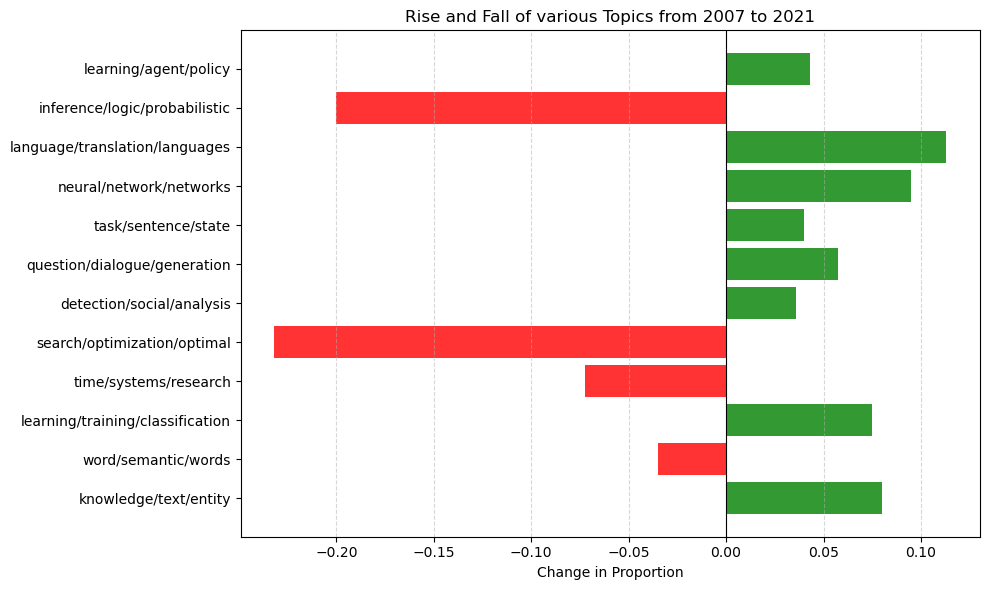

In [16]:
if YEARS_RANGE[0] in period_topics_lda.index and YEARS_RANGE[-1] in period_topics_lda.index :
    topic_change = period_topics_lda.loc[YEARS_RANGE[-1]]-period_topics_lda.loc[YEARS_RANGE[0]]
    topic_change.index = topic_labels.values()
    fig,ax = plt.subplots(figsize=(10,6))
    clrs = []
    for diff in topic_change.values:
        if diff<0:
            clrs.append('red')
        else:
            clrs.append('green')
    ax.barh(topic_change.index,topic_change.values,color=clrs,alpha=0.8)
    ax.axvline(0,color='black',linewidth=0.8)
    ax.set_xlabel('Change in Proportion')
    ax.set_title('Rise and Fall of various Topics from 2007 to 2021')
    ax.grid(axis='x',linestyle='--',alpha=0.5)
    plt.tight_layout()
    plt.savefig('final_figures/axis1_lda_topic_change.png',dpi=150,bbox_inches='tight')
    plt.show()

## Axis 2

In [17]:
df_textrank['year_bin'] = df_textrank['year_bin'].astype(str).str.replace('\u2013','-').str.strip()
period_selected = '2017-2021'
txt_rank_2017 = (df_textrank[df_textrank['year_bin'] == period_selected].sort_values('count',ascending=False).head(10))
print("TextRank's Top 10 keywords for 2017-2021 :")
print(txt_rank_2017[['keyphrases','count']].to_string(index=False))

TextRank's Top 10 keywords for 2017-2021 :
                  keyphrases  count
 natural language processing    416
         deep neural network    297
              neural network    270
    recurrent neural network    205
                        bert    186
convolutional neural network    180
  neural machine translation    177
            machine learning    166
         machine translation    150
             word embeddings    135


In [18]:
df_classifier['period'] = df_classifier['period'].astype(str).str.strip()
yr_2017 = df_classifier[df_classifier['period'] == period_selected].copy()
coeff_pos = yr_2017[yr_2017['direction'] == 'positive'].nlargest(10,'coefficient')
coeff_neg = yr_2017[yr_2017['direction'] == 'negative'].nsmallest(10,'coefficient')
coeff_both = pd.concat([coeff_pos,coeff_neg]).sort_values('coefficient',ascending=True)
print('Logistic Regression classifier - Top Discriminative Words for 2017-2021 :')
print(coeff_both[['word','coefficient']].to_string(index=False))

Logistic Regression classifier - Top Discriminative Words for 2017-2021 :
                word  coefficient
         data mining    -1.831014
planning competition    -1.572467
    knowledge domain    -1.502531
  recognition system    -1.478868
  possibility theory    -1.476620
   learning problems    -1.461173
   logic programming    -1.406639
   influence diagram    -1.393497
  global constraints    -1.391287
    network language    -1.382516
     neural networks     2.219308
        low resource     2.231530
      code available     2.241492
     language models     2.307864
      self attention     2.360434
   data augmentation     2.390649
  federated learning     2.548777
        graph neural     2.621196
       deep learning     3.275130
         pre trained     3.304535


### Different Methods and their interpretations across various periods

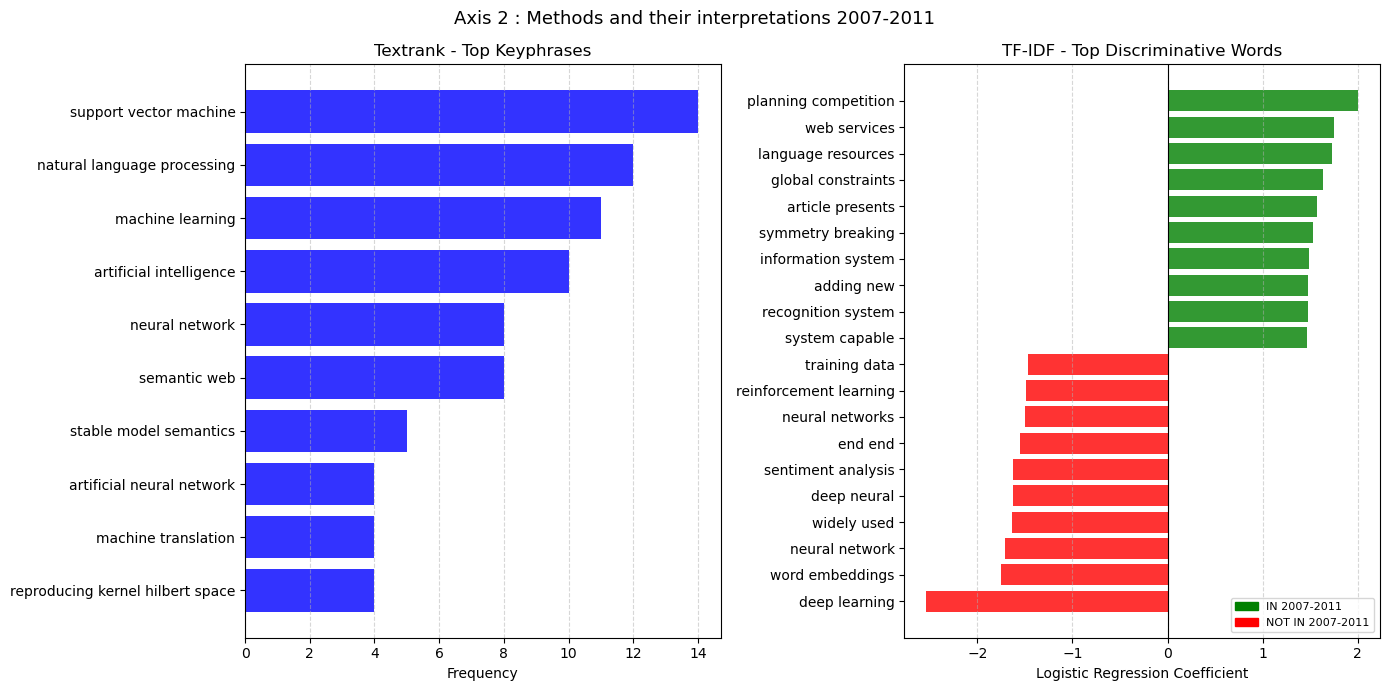

In [19]:
period_selected = '2007-2011'
txt_rank_period = (df_textrank[df_textrank['year_bin'] == period_selected].sort_values('count',ascending=False).head(10))
yr_period = df_classifier[df_classifier['period'] == period_selected].copy()
coeff_pos = yr_period[yr_period['direction'] == 'positive'].nlargest(10,'coefficient')
coeff_neg = yr_period[yr_period['direction'] == 'negative'].nsmallest(10,'coefficient')
coeff_both = pd.concat([coeff_pos,coeff_neg]).sort_values('coefficient', ascending=True)

fig,axes = plt.subplots(1,2,figsize=(14,7))
fig.suptitle(f'Axis 2 : Methods and their interpretations 2007-2011',fontsize=13)

# textrank
ax = axes[0]
if not txt_rank_period.empty:
    ax.barh(txt_rank_period['keyphrases'].values[::-1],txt_rank_period['count'].values[::-1],color='blue',alpha=0.8)
ax.set_title('Textrank - Top Keyphrases')
ax.set_xlabel('Frequency')
ax.grid(axis='x',linestyle='--',alpha=0.5)

# logistic regression
ax = axes[1]
if not coeff_both.empty:
    bar_clrs = []
    for c in coeff_both['coefficient']:
        if c<0:
            bar_clrs.append('red')
        else:
            bar_clrs.append('green')
    ax.barh(coeff_both['word'],coeff_both['coefficient'],color=bar_clrs,alpha=0.8)
    ax.axvline(0, color='black',linewidth=0.8)
ax.set_title('TF-IDF - Top Discriminative Words')
ax.set_xlabel('Logistic Regression Coefficient')
ax.grid(axis='x',linestyle='--',alpha=0.5)
legend_patches = [mpatches.Patch(color='green',label=f'IN 2007-2011'),mpatches.Patch(color='red',label=f'NOT IN 2007-2011')]
ax.legend(handles=legend_patches,fontsize=8,loc='lower right')

plt.tight_layout()
plt.savefig('final_figures/axis2_2007_2011.png',dpi=150,bbox_inches='tight')
plt.show()

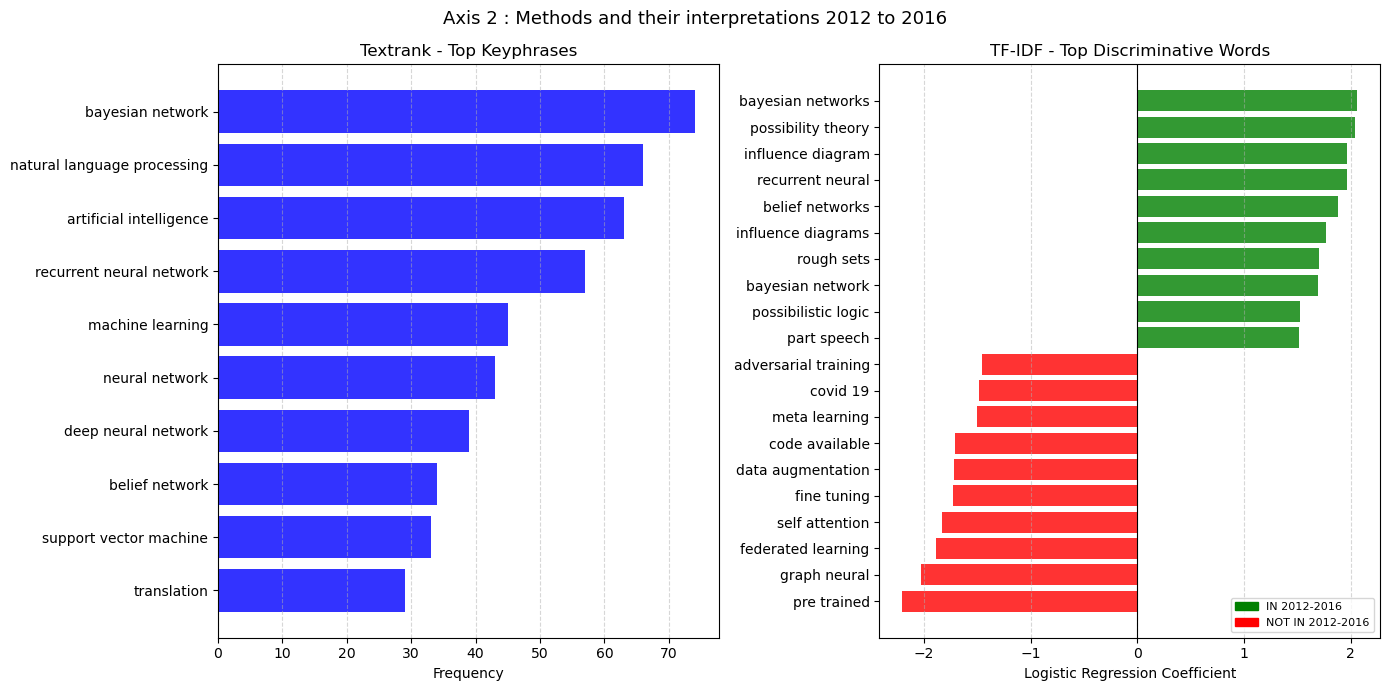

In [20]:
period_selected = '2012-2016'
txt_rank_period = (df_textrank[df_textrank['year_bin'] == period_selected].sort_values('count',ascending=False).head(10))
yr_period = df_classifier[df_classifier['period'] == period_selected].copy()
coeff_pos = yr_period[yr_period['direction'] == 'positive'].nlargest(10,'coefficient')
coeff_neg = yr_period[yr_period['direction'] == 'negative'].nsmallest(10,'coefficient')
coeff_both = pd.concat([coeff_pos,coeff_neg]).sort_values('coefficient',ascending=True)

fig,axes = plt.subplots(1,2,figsize=(14,7))
fig.suptitle(f'Axis 2 : Methods and their interpretations 2012 to 2016',fontsize=13)

# textrank
ax = axes[0]
if not txt_rank_period.empty:
    ax.barh(txt_rank_period['keyphrases'].values[::-1],txt_rank_period['count'].values[::-1],color='blue',alpha=0.8)
ax.set_title('Textrank - Top Keyphrases')
ax.set_xlabel('Frequency')
ax.grid(axis='x',linestyle='--',alpha=0.5)

# logistic regression
ax = axes[1]
if not coeff_both.empty:
    bar_clrs = []
    for c in coeff_both['coefficient']:
        if c<0:
            bar_clrs.append('red')
        else:
            bar_clrs.append('green')
    ax.barh(coeff_both['word'],coeff_both['coefficient'],color=bar_clrs,alpha=0.8)
    ax.axvline(0, color='black',linewidth=0.8)
ax.set_title('TF-IDF - Top Discriminative Words')
ax.set_xlabel('Logistic Regression Coefficient')
ax.grid(axis='x',linestyle='--',alpha=0.5)
legend_patches = [mpatches.Patch(color='green',label=f'IN 2012-2016'),mpatches.Patch(color='red',label=f'NOT IN 2012-2016')]
ax.legend(handles=legend_patches,fontsize=8,loc='lower right')

plt.tight_layout()
plt.savefig('final_figures/axis2_2012_2016.png',dpi=150,bbox_inches='tight')
plt.show()

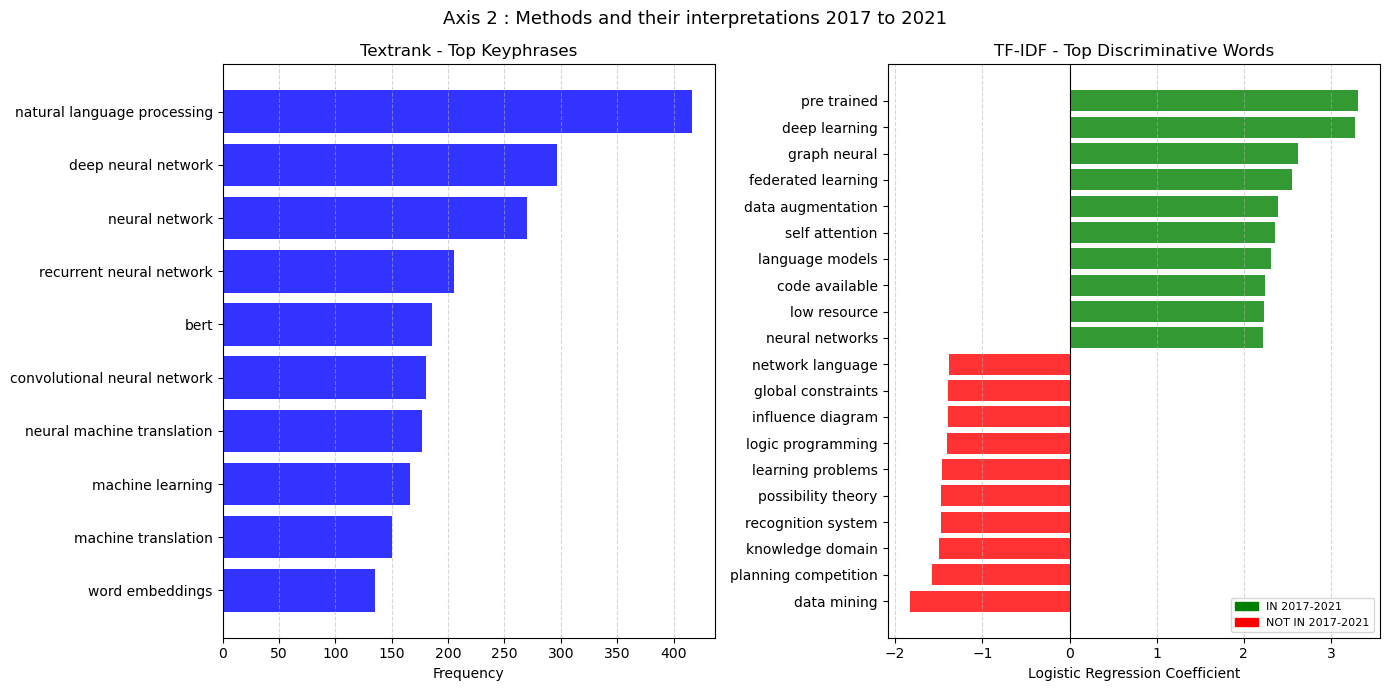

In [21]:
period_selected = '2017-2021'
txt_rank_period = (df_textrank[df_textrank['year_bin'] == period_selected].sort_values('count',ascending=False).head(10))
yr_period = df_classifier[df_classifier['period'] == period_selected].copy()
coeff_pos = yr_period[yr_period['direction'] == 'positive'].nlargest(10,'coefficient')
coeff_neg = yr_period[yr_period['direction'] == 'negative'].nsmallest(10,'coefficient')
coeff_both = pd.concat([coeff_pos,coeff_neg]).sort_values('coefficient',ascending=True)

fig, axes = plt.subplots(1,2,figsize=(14,7))
fig.suptitle(f'Axis 2 : Methods and their interpretations 2017 to 2021',fontsize=13)

# textrank
ax = axes[0]
if not txt_rank_period.empty:
    ax.barh(txt_rank_period['keyphrases'].values[::-1],txt_rank_period['count'].values[::-1],color='blue',alpha=0.8)
ax.set_title('Textrank - Top Keyphrases')
ax.set_xlabel('Frequency')
ax.grid(axis='x',linestyle='--',alpha=0.5)

# logistic regression
ax = axes[1]
if not coeff_both.empty:
    bar_clrs = []
    for c in coeff_both['coefficient']:
        if c<0:
            bar_clrs.append('red')
        else:
            bar_clrs.append('green')
    ax.barh(coeff_both['word'],coeff_both['coefficient'],color=bar_clrs,alpha=0.8)
    ax.axvline(0,color='black',linewidth=0.8)
ax.set_title('TF-IDF - Top Discriminative Words')
ax.set_xlabel('Logistic Regression Coefficient')
ax.grid(axis='x',linestyle='--',alpha=0.5)
legend_patches = [mpatches.Patch(color='green',label=f'IN 2017-2021'),mpatches.Patch(color='red',label=f'NOT IN 2017-2021')]
ax.legend(handles=legend_patches,fontsize=8,loc='lower right')

plt.tight_layout()
plt.savefig('final_figures/axis2_2017_2021.png',dpi=150,bbox_inches='tight')
plt.show()

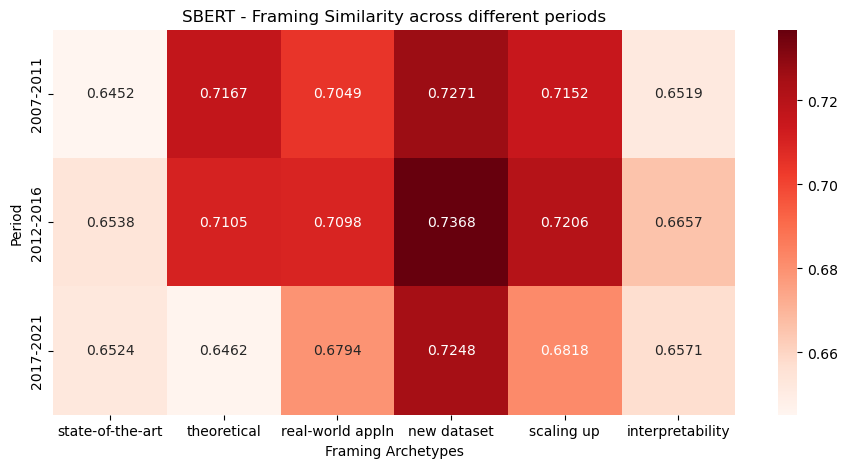

In [22]:
import seaborn as sns
fig,ax = plt.subplots(figsize=(11,5))
framing_plot = df_framing.T    # to make periods as rows
sns.heatmap(framing_plot,ax=ax,annot=True,fmt='.4f',cmap='Reds')
ax.set_title('SBERT - Framing Similarity across different periods')
ax.set_xlabel('Framing Archetypes')
ax.set_ylabel('Period')

plt.savefig('final_figures/axis2_sbert_framing_heatmap.png',dpi=150,bbox_inches='tight')
plt.show()

## Summary

In [23]:
final_rows = []
for method,dists in dist_results.items():
    final_rows.append({'Methods': method,'2007-2011 to 2012-2016' : round(dists[0],4),'2012-2016 to 2017-2021' : round(dists[1],4)})
final_table = pd.DataFrame(final_rows)
print('Distances across Methods')
print(final_table.to_string(index=False))

Distances across Methods
        Methods  2007-2011 to 2012-2016  2012-2016 to 2017-2021
         TF-IDF                  0.2595                  0.2889
 SBERT - MiniLM                  0.0461                  0.1221
SBERT - Specter                  0.0055                  0.0298
  SBERT - MPNet                  0.0500                  0.1388
            LDA                  0.0270                  0.2733


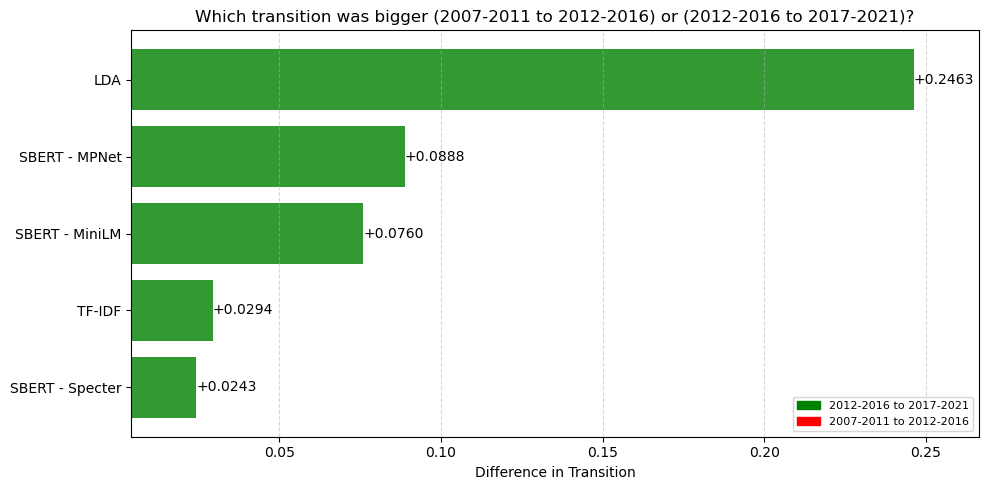

In [24]:
difference = {}
for method,dists in dist_results.items():
    difference[method] = round(dists[1]-dists[0],4)
difference_series = pd.Series(difference).sort_values()

fig,ax = plt.subplots(figsize=(10,5))
clrs = []
for v in difference_series.values:
    if v>0:
        clrs.append('green')
    else:
        clrs.append('red')
ax.barh(difference_series.index,difference_series.values,color=clrs,alpha=0.8)
ax.axvline(0,color='black')
for i,(name,val) in enumerate(difference_series.items()):
    ax.text(val,i,f'{val:+.4f}',va='center',fontsize=10)
ax.set_xlabel('Difference in Transition')
ax.set_title('Which transition was bigger (2007-2011 to 2012-2016) or (2012-2016 to 2017-2021)?')
ax.grid(axis='x',linestyle='--',alpha=0.5)
ax.set_xlim(difference_series.min()-0.02,difference_series.max()+0.02)
legend_patches = [mpatches.Patch(color='green',label='2012-2016 to 2017-2021'),mpatches.Patch(color='red',label='2007-2011 to 2012-2016')]
ax.legend(handles=legend_patches,fontsize=8,loc='lower right')
plt.tight_layout()
plt.savefig('final_figures/axis1_transition_year_range_comparison.png',dpi=150,bbox_inches='tight')
plt.show()